In [7]:
## mercator explore data
import xarray as xr
import matplotlib.pyplot as plt

In [13]:
pathUVW = '/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/'
pathTS = "/work/bk1450/b383184/Amazon/Mercator/data/variables_c/tracers/"

ufiles = f"{pathUVW}/U_1993-01c.nc"
vfiles = f"{pathUVW}/V_1993-01c.nc"
wfiles = f"{pathUVW}/W_1993-02fc.nc"
sfiles = f"{pathTS}/S_1993-01c.nc"
tfiles = f"{pathTS}/T_1993-01c.nc"

In [14]:
## mesh
ds_Hgr = xr.open_dataset('../data/Hgr_mesh.nc')
ds_Hgr

<xarray.Dataset> Size: 1GB
Dimensions:       (y: 3059, x: 4322, z: 50, t: 1)
Dimensions without coordinates: y, x, z, t
Data variables: (12/21)
    nav_lon       (y, x) float32 53MB ...
    nav_lat       (y, x) float32 53MB ...
    nav_lev       (z) float32 200B ...
    time_counter  (t) float64 8B ...
    glamt         (t, y, x) float32 53MB ...
    glamu         (t, y, x) float32 53MB ...
    ...            ...
    e1f           (t, y, x) float64 106MB ...
    e2t           (t, y, x) float64 106MB ...
    e2u           (t, y, x) float64 106MB ...
    e2v           (t, y, x) float64 106MB ...
    e2f           (t, y, x) float64 106MB ...
    ff            (t, y, x) float64 106MB ...
Attributes:
    file_name:            mesh_hgr.nc
    TimeStamp:            03/02/2016 10:24:55 -0000
    Unlimited_Dimension:  t

In [15]:
import numpy as np

def desired_axis(lon0,lon1,lat0,lat1):
    # lon0, lon1 = int,int
    # lat0, lat1 = int,int
    
    # 1) Use T-point lon/lat
    lonT = ds_Hgr.glamt.isel(t=0)
    latT = ds_Hgr.gphit.isel(t=0)
    
    # 2) Build boolean mask for your box
    mask = (lonT >= lon0) & (lonT <= lon1) & (latT >= lat0) & (latT <= lat1)
    
    # 3) Get index ranges
    yy, xx = np.where(mask.values)
    
    y0, y1 = int(yy.min()), int(yy.max())
    x0, x1 = int(xx.min()), int(xx.max())
    
    return x0, x1, y0, y1

In [16]:
def axes_to_lonlat(x0, x1, y0, y1):
    lonT = ds_Hgr.glamt.isel(t=0)
    latT = ds_Hgr.gphit.isel(t=0)

    sub_lon = lonT.isel(x=slice(x0, x1+1), y=slice(y0, y1+1))
    sub_lat = latT.isel(x=slice(x0, x1+1), y=slice(y0, y1+1))

    lon_min = float(sub_lon.min())
    lon_max = float(sub_lon.max())
    lat_min = float(sub_lat.min())
    lat_max = float(sub_lat.max())
    return lon_min, lon_max, lat_min, lat_max

In [17]:
dsU = xr.open_dataset(ufiles)
dsS = xr.open_dataset(sfiles)
dsW = xr.open_dataset(wfiles)
dsV = xr.open_dataset(vfiles)
dsT = xr.open_dataset(tfiles)

In [18]:
x0, x1, y0, y1 = desired_axis(-50, -48,-1,2)
lon0, lon1, lat0, lat1 = desired_axis(-50, -48,-0.5,1)

# lon0 = -50
# lon1 = -48
# lat1 = 1
# lat0 = -0.5

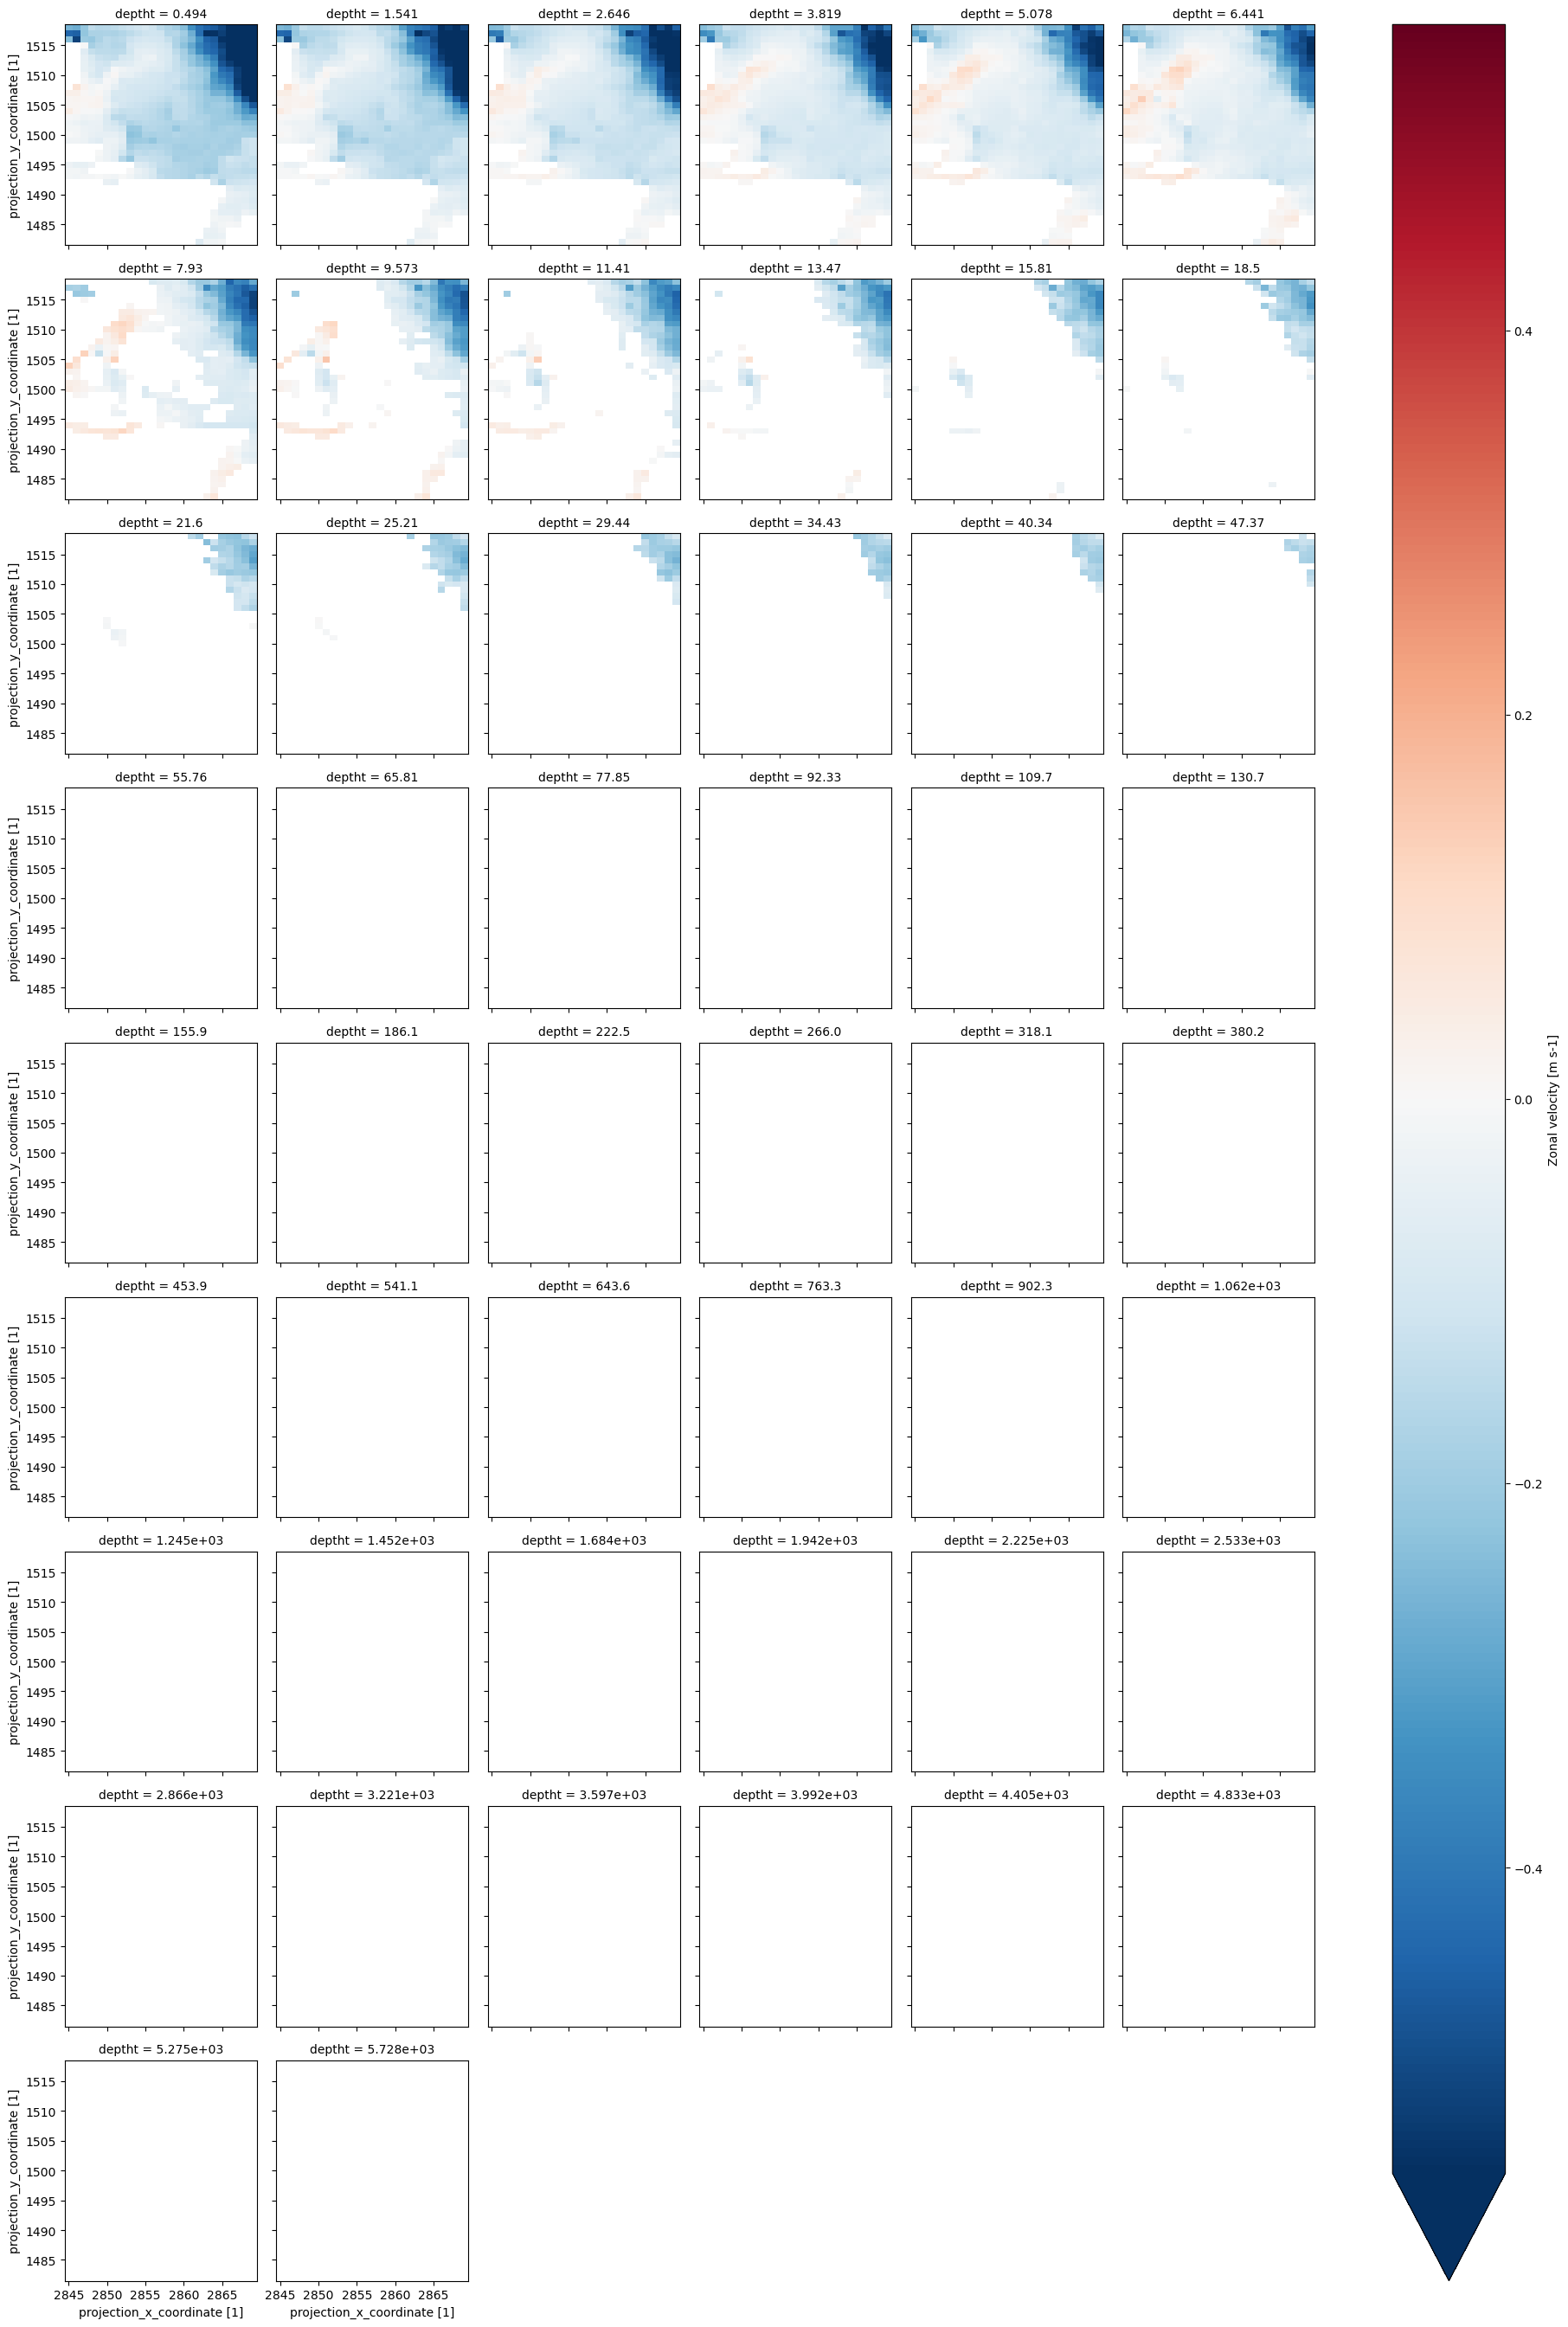

In [19]:
dsU.isel(time_counter=0).sel(x=slice(x0,x1),y=slice(y0,y1)).vozocrtx.plot(x='x', y='y', col='deptht', col_wrap=6, robust=True)

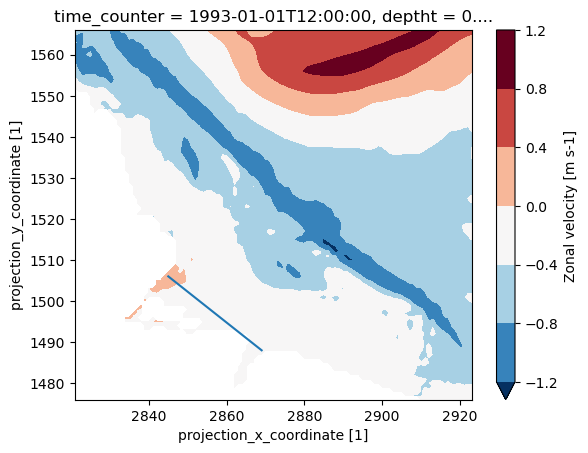

In [20]:
x0, x1, y0, y1 = desired_axis(-52, -43.5,-1.5,6)
dsU.isel(time_counter=0,deptht=0).sel(x=slice(x0,x1),y=slice(y0,y1)).vozocrtx.plot.contourf(x='x', y='y',robust=True)

plt.plot([lon0,lon1], [lat1,lat0])

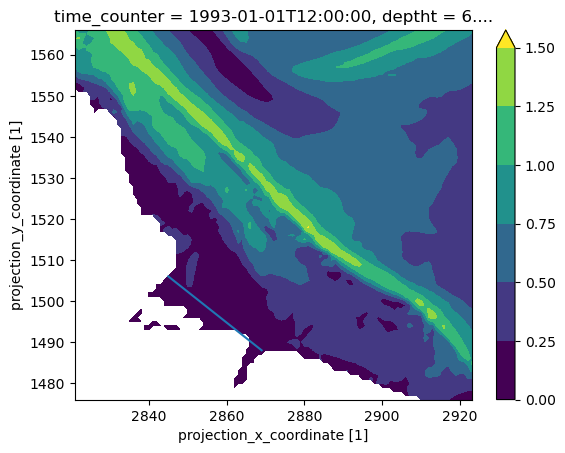

In [21]:
((dsV.isel(time_counter=0).vomecrty**2 + 
  dsU.isel(time_counter=0).vozocrtx**2)**0.5).isel(deptht=5).sel(
    x=slice(x0,x1),y=slice(y0,y1)).plot.contourf(x='x', y='y',robust=True)
plt.plot([lon0,lon1], [lat1,lat0])

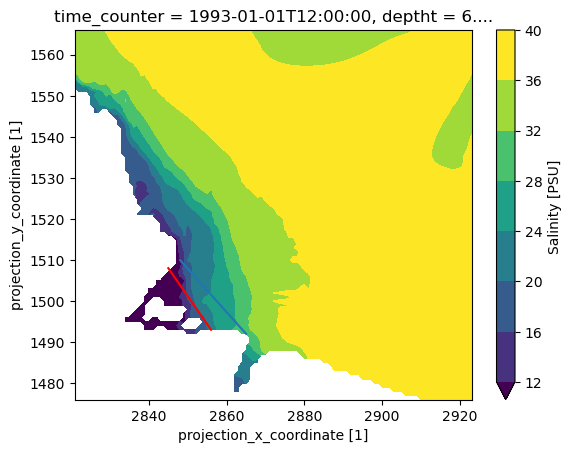

In [22]:
x0, x1, y0, y1 = desired_axis(-52, -43.5,-1.5,6)
lon0, lon1, lat0, lat1 = desired_axis(-50, -48,-1,0.5)

dsS.isel(time_counter=0,deptht=5).sel(x=slice(x0,x1),y=slice(y0,y1)).vosaline.plot.contourf(x='x', y='y',robust=True)

plt.plot([2860-15,2865-9],[1510-2 ,1493],color='red')
plt.plot([2860-12,2865],[1510 ,1492])

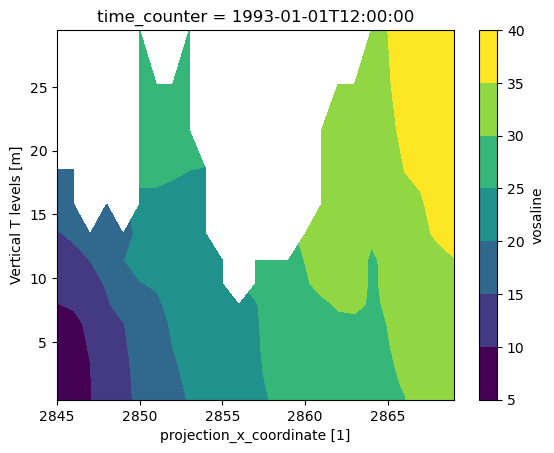

In [23]:
x0, x1, y0, y1 = desired_axis(-50, -48,-1,2)
dsS.isel(time_counter=0,deptht=slice(0,15)).sel(x=slice(x0,x1),y=slice(y0,y1)).vosaline.mean(dim='y').plot.contourf()

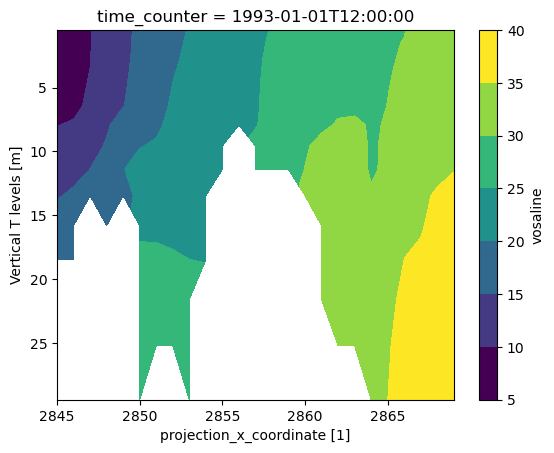

In [24]:
h = (dsS.isel(time_counter=0, deptht=slice(0,15))
        .sel(x=slice(x0,x1), y=slice(y0,y1))
        .vosaline.mean('y')
        .plot.contourf())
h.axes.invert_yaxis()

### W fixed

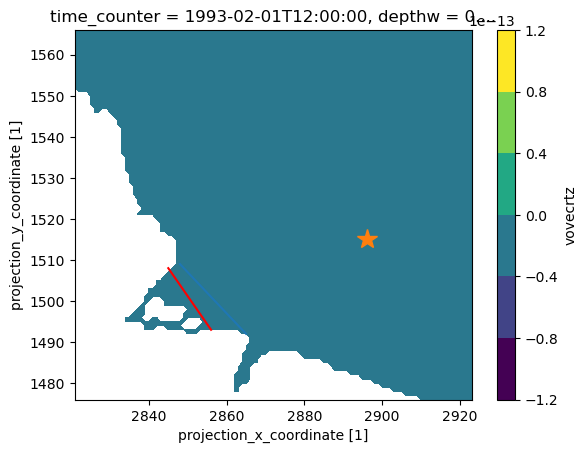

In [25]:
x0, x1, y0, y1 = desired_axis(-52, -43.5,-1.5,6)
lon0, lon1, lat0, lat1 = desired_axis(-49.75, -48.33,-0.17,1.33)

dsW.isel(time_counter=0,depthw=0).sel(x=slice(x0,x1),y=slice(y0,y1)).vovecrtz.plot.contourf(x='x', y='y',robust=True)
plt.plot([2860-15,2865-9],[1510-2 ,1493],color='red')
plt.plot([lon0,lon1], [lat1,lat0])

plt.plot(2896, 1515,marker='*',markersize=15)

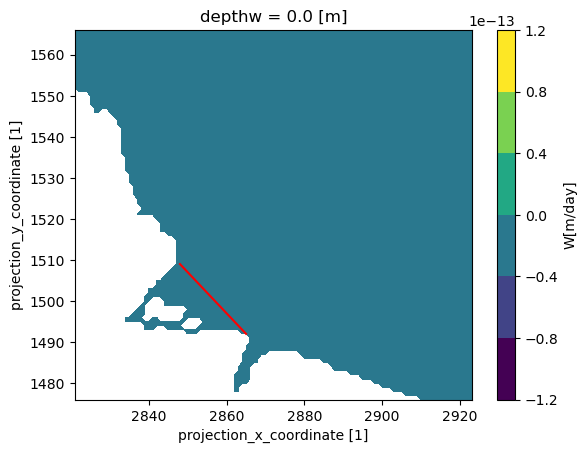

In [26]:
(dsW.std('time_counter').isel(
    depthw=0).sel(x=slice(x0,x1),y=slice(y0,y1)).vovecrtz* 24 * 3600).rename("W[m/day]").plot.contourf(x='x', y='y',robust=True)
plt.plot([lon0,lon1], [lat1,lat0],color='red')
# plt.plot([2860-15,2865-9],[1510-2 ,1493],color='red')

In [27]:
lon0, lon1, lat0, lat1 = axes_to_lonlat(2860-14,2865-9,1493,1510-2)
print(lon0, lon1, lat0, lat1)


-49.91666793823242 -49.08333206176758 -0.08333330601453781 1.1665860414505005


In [28]:
# dsW.isel(x=_x, y=_y, time_counter=_t)

NameError: name '_x' is not defined

### SSH 

In [32]:
sshfiles = f"{pathTS}/SSH_1993-01c.nc"
dsSSH= xr.open_dataset(sshfiles,engine='netcdf4')
dsSSH

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'sossheig' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


<xarray.Dataset> Size: 161MB
Dimensions:       (x: 1260, y: 499, time_counter: 31)
Coordinates:
  * x             (x) int32 5kB 2306 2307 2308 2309 2310 ... 3562 3563 3564 3565
  * y             (y) int32 2kB 1375 1376 1377 1378 1379 ... 1870 1871 1872 1873
  * time_counter  (time_counter) datetime64[ns] 248B 1993-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB ...
    nav_lat       (y, x) float32 3MB ...
Data variables:
    sossheig      (time_counter, y, x) float64 156MB ...

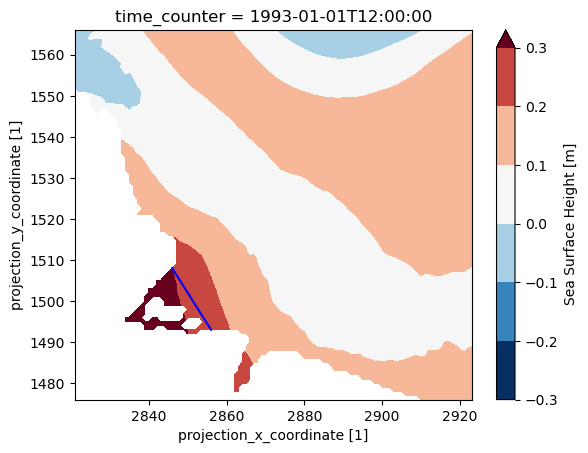

In [33]:
x0, x1, y0, y1 = desired_axis(-52, -43.5,-1.5,6)
lon0, lon1, lat0, lat1 = desired_axis(-49.75, -48.33,-0.17,1.33)

dsSSH.isel(time_counter=0).sel(x=slice(x0,x1),y=slice(y0,y1)).sossheig.plot.contourf(x='x', y='y',robust=True)
plt.plot([2860-14,2865-9],[1510-2 ,1493],color='blue')

# plt.plot([lon0,lon1], [lat1,lat0])

### Comparison of S,T,U,V,W 
Determine what is the best depth to release particles

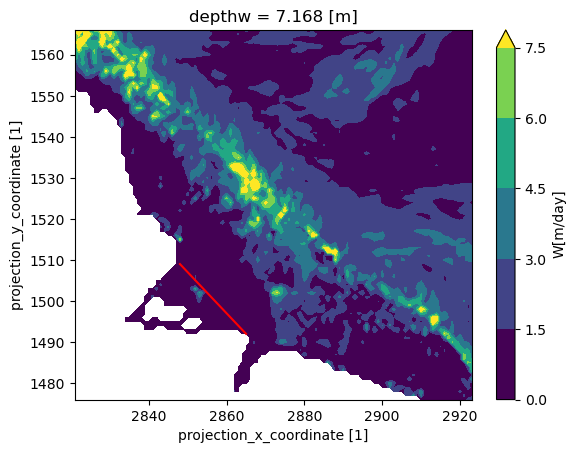

In [41]:
(dsW.std('time_counter').isel(
    depthw=6).sel(x=slice(x0,x1),y=slice(y0,y1)).vovecrtz* 24 * 3600).rename("W[m/day]").plot.contourf(x='x', y='y',robust=True)
plt.plot([lon0,lon1], [lat1,lat0],color='red')

* Best depth is 7m